In [79]:
import librosa
import librosa.display
import scipy as sp
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft,fftshift, fftfreq, ifft, ifftshift

In [80]:
# load audio file in the player
audio_path = "/content/piano_c.wav"
ipd.Audio(filename=audio_path)

In [81]:
# load audio file
signal, sr = librosa.load(audio_path)

In [82]:
sr

22050

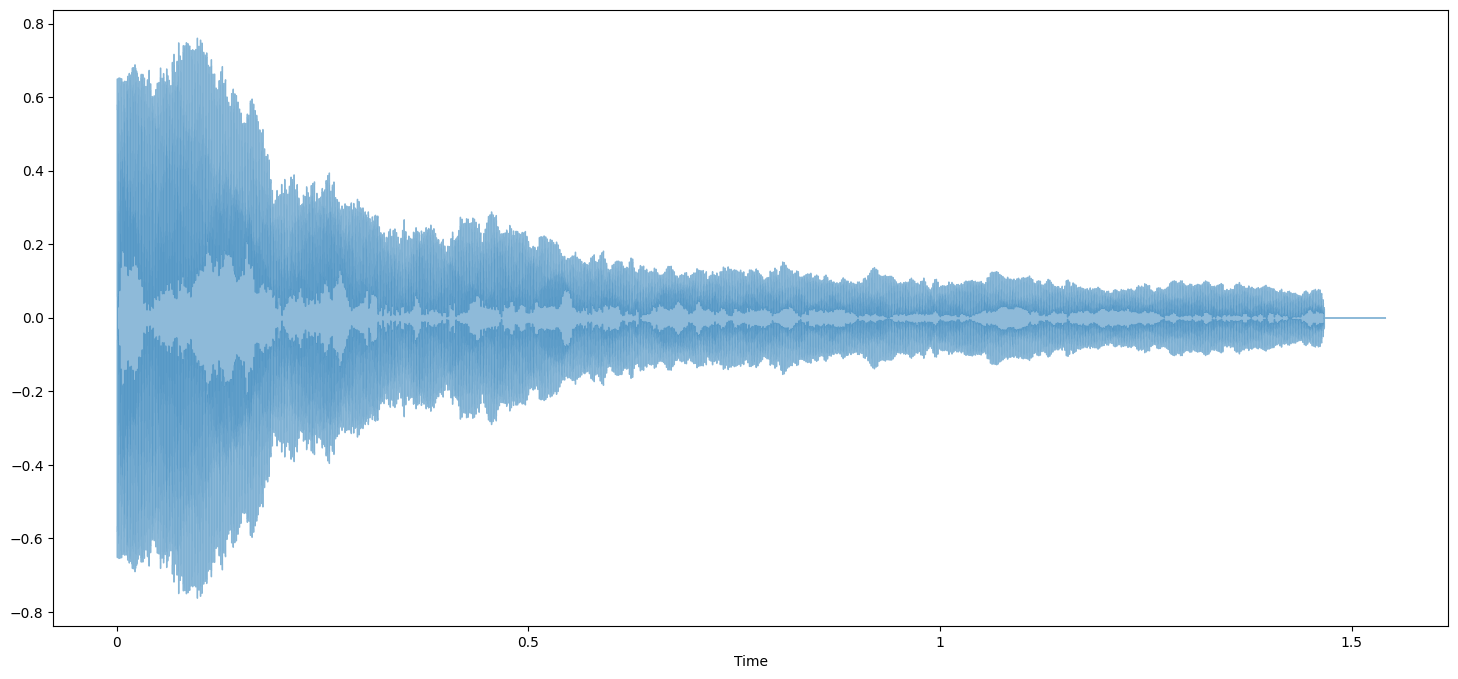

In [83]:
# plot waveform
plt.figure(figsize=(18, 8))
librosa.display.waveshow(signal, sr=sr, alpha=0.5)
plt.show()

In [84]:
# derive spectrum using FT
ft = sp.fft.fft(signal)
magnitude = np.absolute(ft)
frequency = np.linspace(0, sr, len(magnitude))

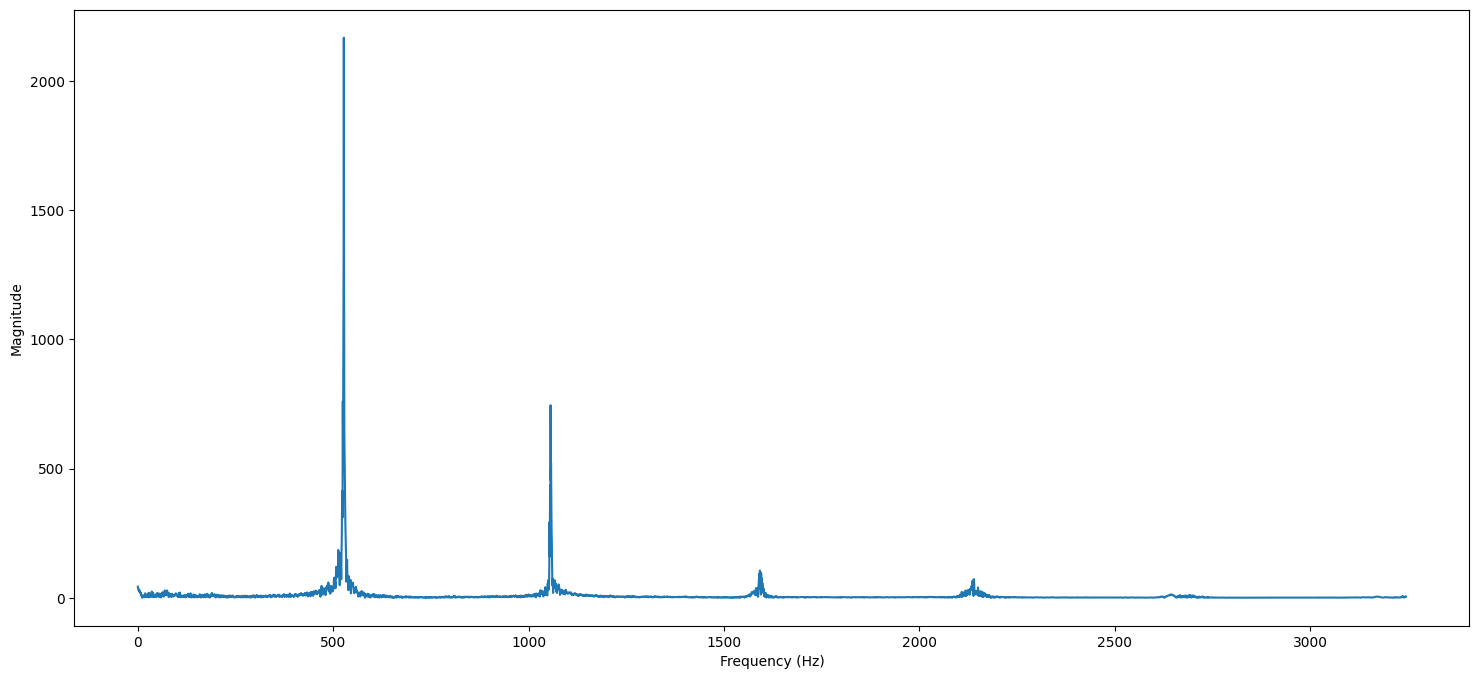

In [85]:
# plot spectrum
plt.figure(figsize=(18, 8))
plt.plot(frequency[:5000], magnitude[:5000]) # magnitude spectrum
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [86]:
len(signal)

33968

In [87]:
d =  1 / sr
d

4.5351473922902495e-05

In [88]:
d_523 = 1 / 523
d_523

0.0019120458891013384

In [89]:
d_400_samples = 400 * d
d_400_samples

0.018140589569160998

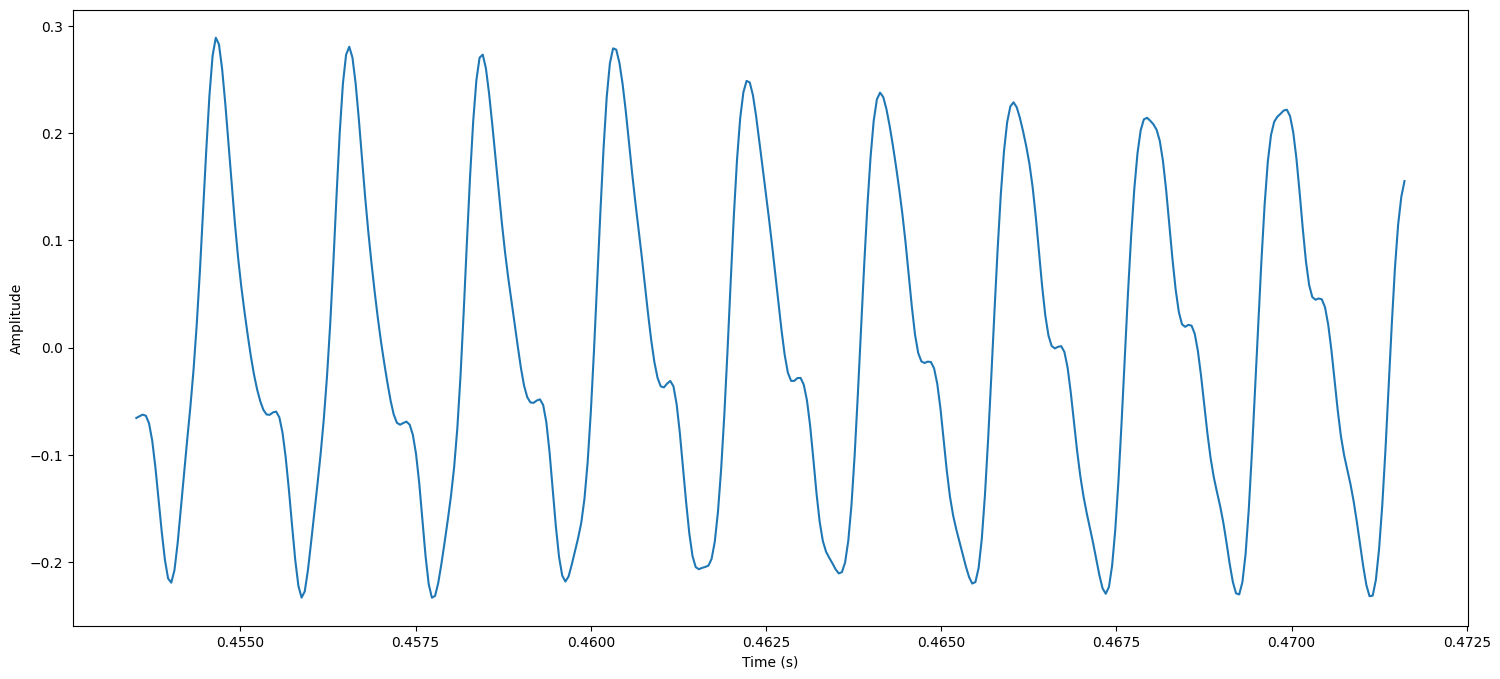

In [90]:
# zomm in to the waveform
samples = range(len(signal))
t = librosa.samples_to_time(samples, sr=sr)

plt.figure(figsize=(18, 8))
plt.plot(t[10000:10400], signal[10000:10400])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

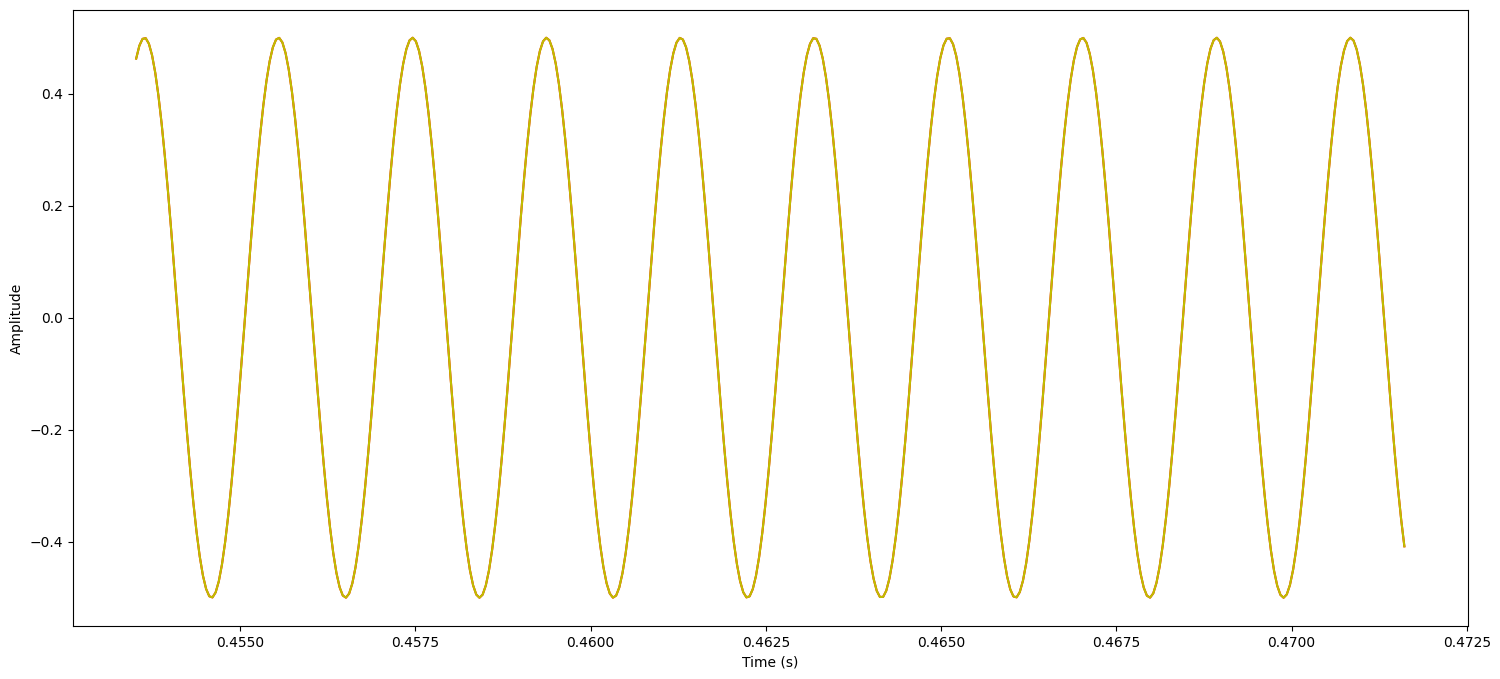

In [91]:
# create a sinusoid

f = 523
phase = 0
phase2 = 2

sin = 0.5 * np.sin(2*np.pi * (f * t - phase))
sin2 = 0.5 * np.sin(2*np.pi * (f * t - phase2))

plt.figure(figsize=(18, 8))
plt.plot(t[10000:10400], sin[10000:10400], color="r")
plt.plot(t[10000:10400], sin2[10000:10400], color="y")


plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

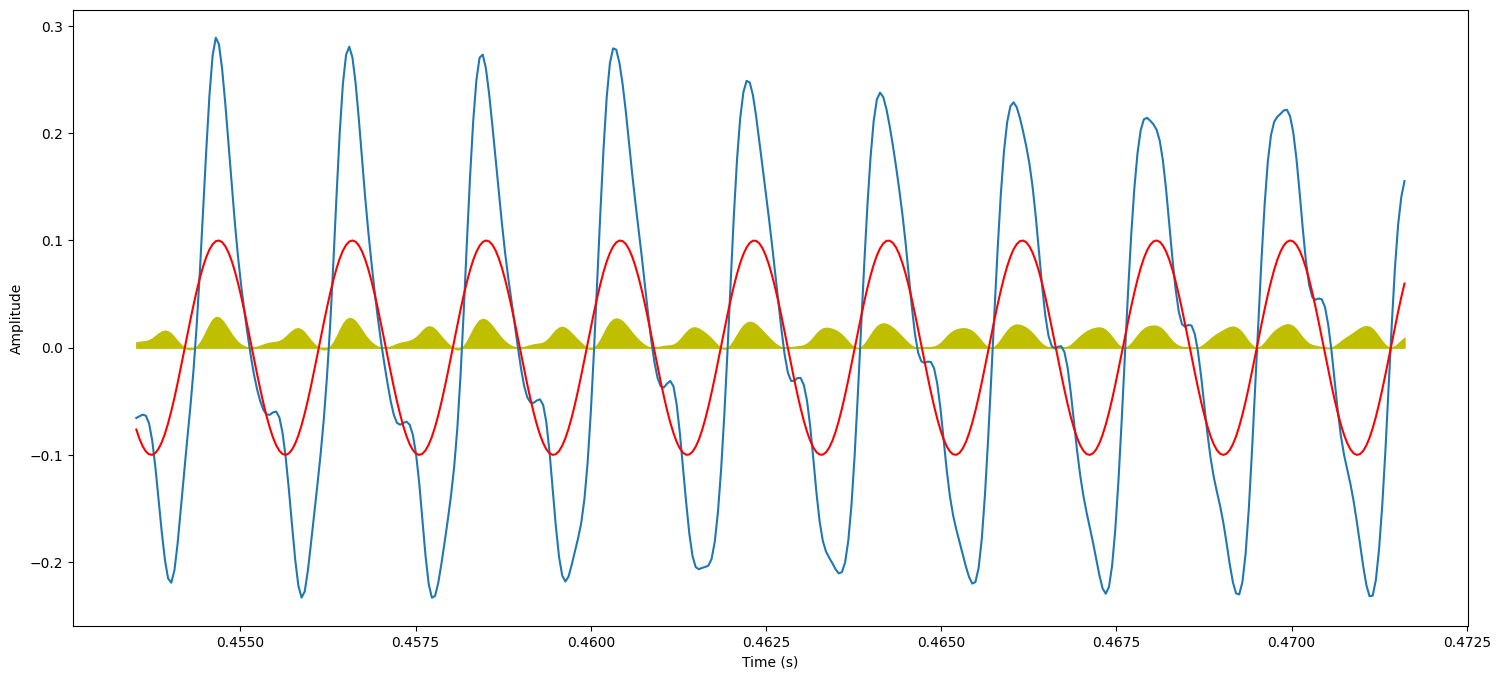

In [96]:
# compare signal and sinusoids

f = 523
phase = 0.55

sin = 0.1 * np.sin(2*np.pi * (f * t - phase))

plt.figure(figsize=(18, 8))
plt.plot(t[10000:10400], signal[10000:10400])
plt.plot(t[10000:10400], sin[10000:10400], color="r")

plt.fill_between(t[10000:10400], sin[10000:10400]*signal[10000:10400], color="y")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


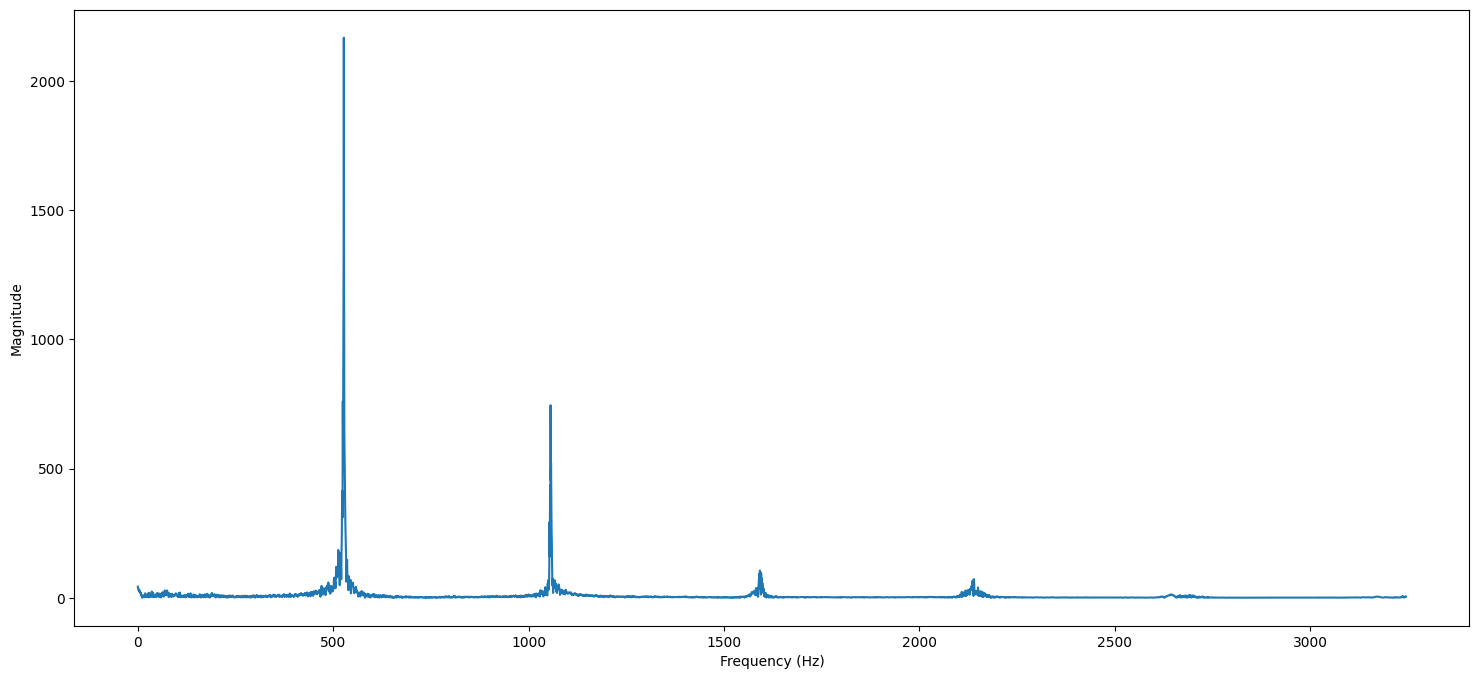

In [68]:
# plot spectrum
plt.figure(figsize=(18, 8))
plt.plot(frequency[:5000], magnitude[:5000]) # magnitude spectrum
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

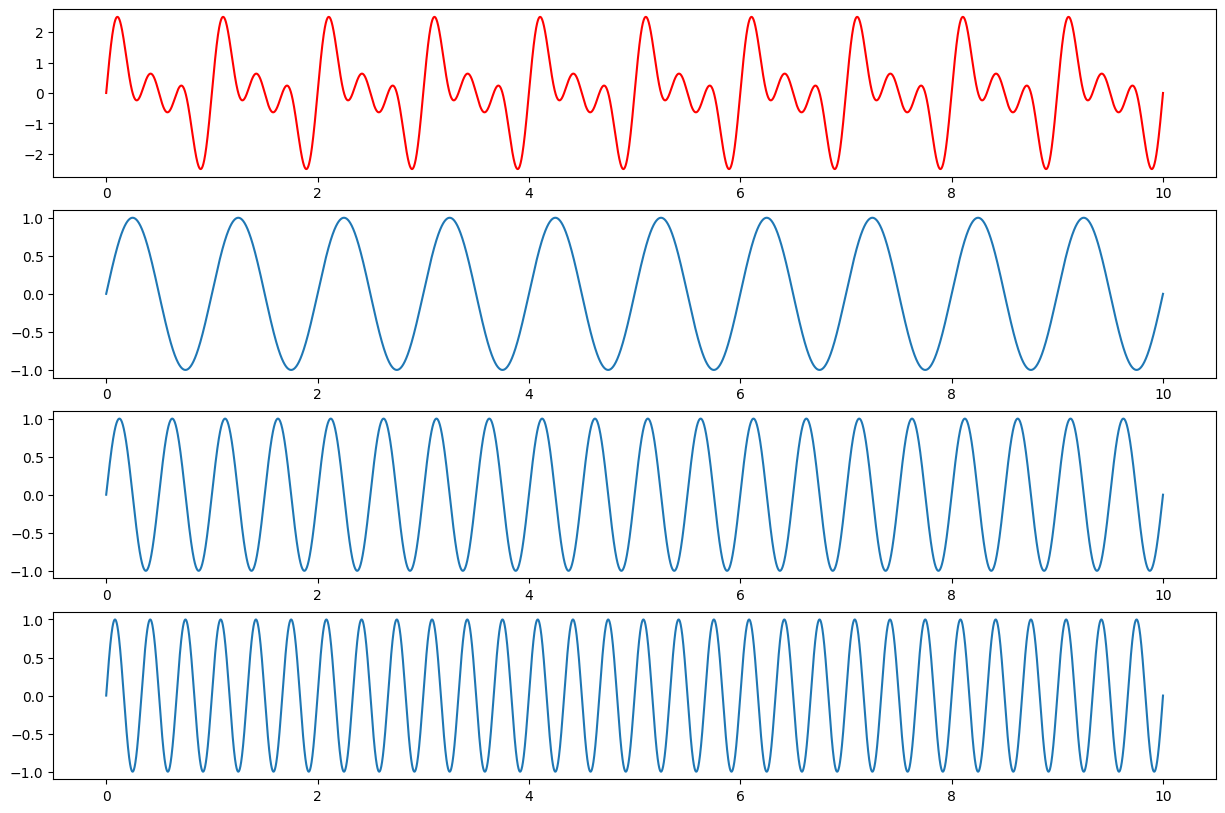

In [69]:
# superimposing pure tones
f = 1
t = np.linspace(0, 10, 10000)

sin = np.sin(2*np.pi * (f * t))
sin2 = 0.5*np.sin(2*np.pi * (2*f * t))
sin3 = np.sin(2*np.pi * (3*f * t))

sum_signal = sin + sin2 + sin3

plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(t, sum_signal, color="r")

plt.subplot(4, 1, 2)
plt.plot(t, sin)

plt.subplot(4, 1, 3)
plt.plot(t, sin2)

plt.subplot(4, 1, 4)
plt.plot(t, sin3)

plt.show()

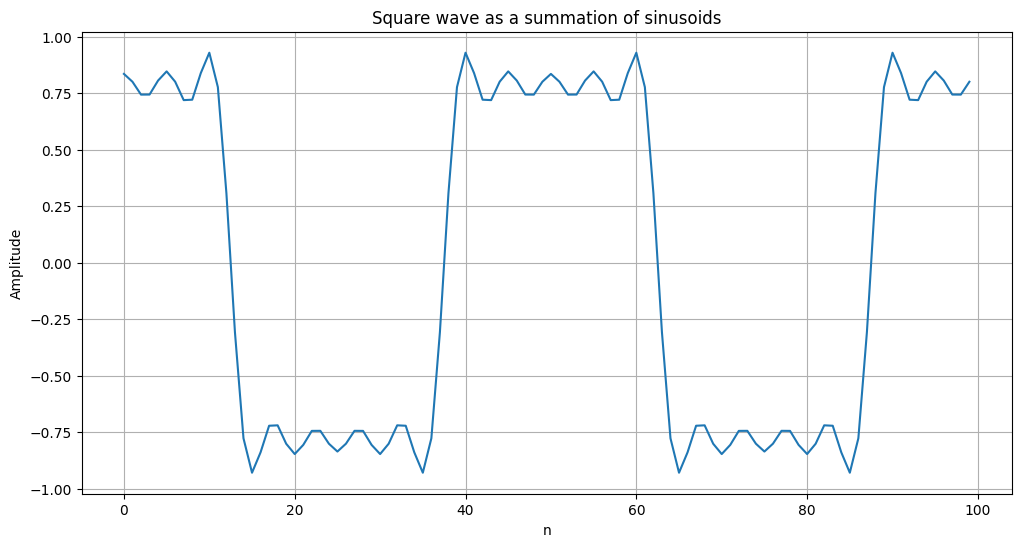

In [70]:
n_cycles_0 = 2
N = 100
pi=np.pi
f0 = n_cycles_0/N

n = np.arange(N)
x = np.cos(2*pi*f0*n) \
     - (1/3)*np.cos(2*pi*(3*f0)*n)  \
     + (1/5)*np.cos(2*pi*(5*f0)*n)  \
     - (1/7)*np.cos(2*pi*(7*f0)*n) \
     + (1/9)*np.cos(2*pi*(9*f0)*n)


# Plotting the result
plt.figure(figsize=(12, 6))
plt.plot(n, x)
plt.title('Square wave as a summation of sinusoids')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [97]:
def perform_fft(x, N):
    X = fft(x)
    X = fftshift(X)
    X = X/N # Normalization

    fk = fftfreq(N)
    fk = fftshift(fk)

    return X, fk

def plot_sig_and_fft(x, n, X, fk):
    fig = plt.figure(figsize=(16, 8))

    plt.subplot(1, 2, 1)
    plt.plot(n, x)
    plt.xlabel("$n$")
    plt.ylabel("$x[n]$")
    plt.title(f"Signal in time domain")

    plt.subplot(1, 2, 2)
    plt.stem(fk, np.abs(X))
    plt.xlabel("Digital frequncy, f")
    plt.title("Magnitude of X [normalized]")

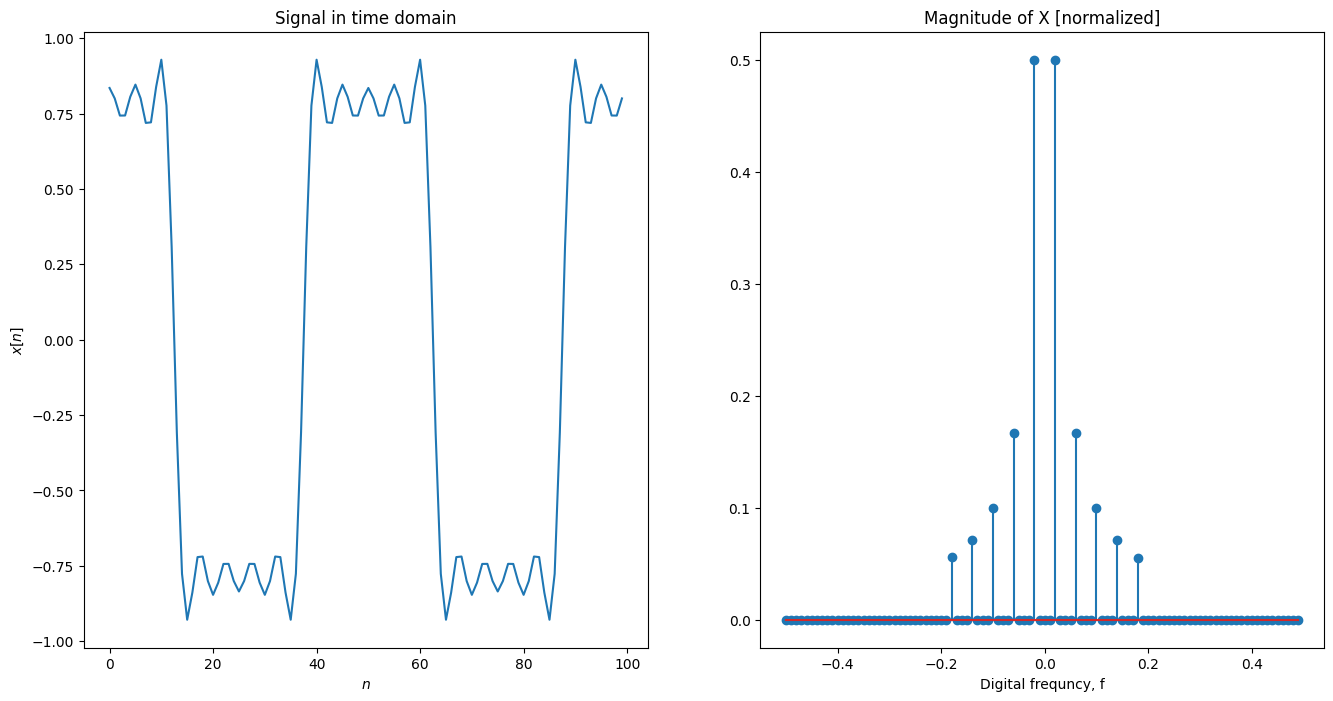

In [72]:
n_cycles_0 = 2
N = 100

f0 = n_cycles_0/N

n = np.arange(N)
x = np.cos(2*pi*f0*n) \
     - (1/3)*np.cos(2*pi*(3*f0)*n)  \
     + (1/5)*np.cos(2*pi*(5*f0)*n)  \
     - (1/7)*np.cos(2*pi*(7*f0)*n) \
     + (1/9)*np.cos(2*pi*(9*f0)*n)
X, fk = perform_fft(x, N)
plot_sig_and_fft(x, n, X, fk)

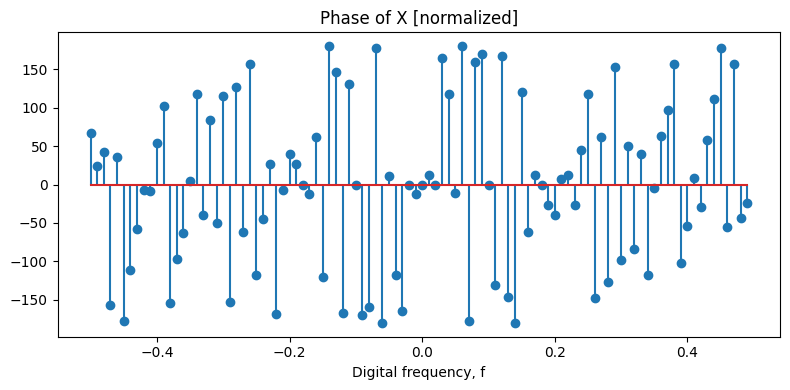

In [73]:
fig = plt.figure(figsize=(8, 4))


plt.stem(fk, np.angle(X)*(180/np.pi))
plt.xlabel("Digital frequency, f")
plt.title("Phase of X [normalized]")

plt.tight_layout()
plt.show()

In [74]:
def perform_ifft(X, N):
    X_ishift = ifftshift(X)
    x_recon = ifft(X_ishift)
    x_recon = np.real(x_recon)*N #Multiplying extra N because we normalized during FFT

    n = np.arange(N)
    if x_recon.shape[0] > N:
        x_recon = x_recon[:N]

    return x_recon, n

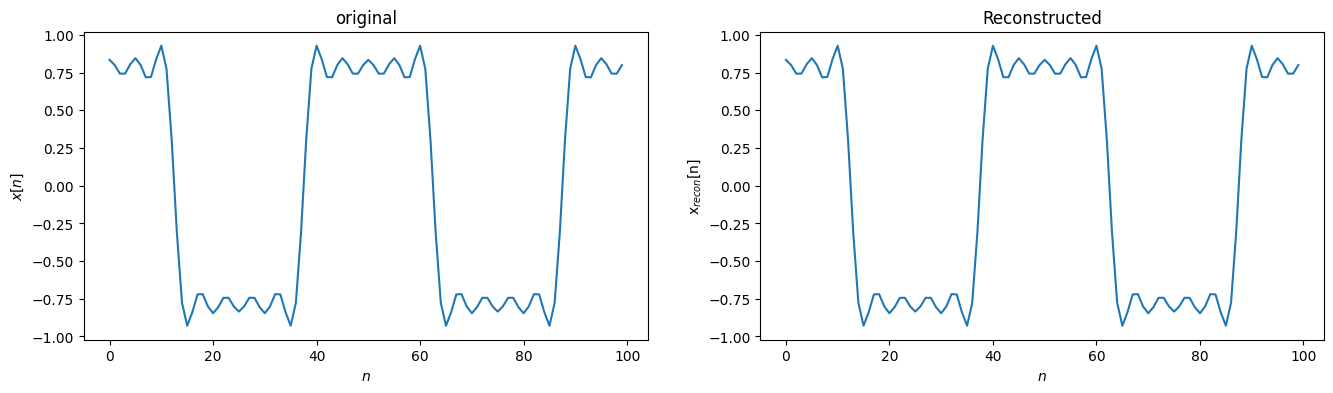

In [75]:
x_recon, n_recon = perform_ifft(X, N)
fig = plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
plt.plot(n, x)
plt.xlabel("$n$")
plt.ylabel("$x[n]$")
plt.title(f"original")

plt.subplot(1, 2, 2)
plt.plot(n_recon, x_recon)
plt.xlabel("$n$")
plt.ylabel("x$_{recon}$[n]")
plt.title("Reconstructed")
plt.show()

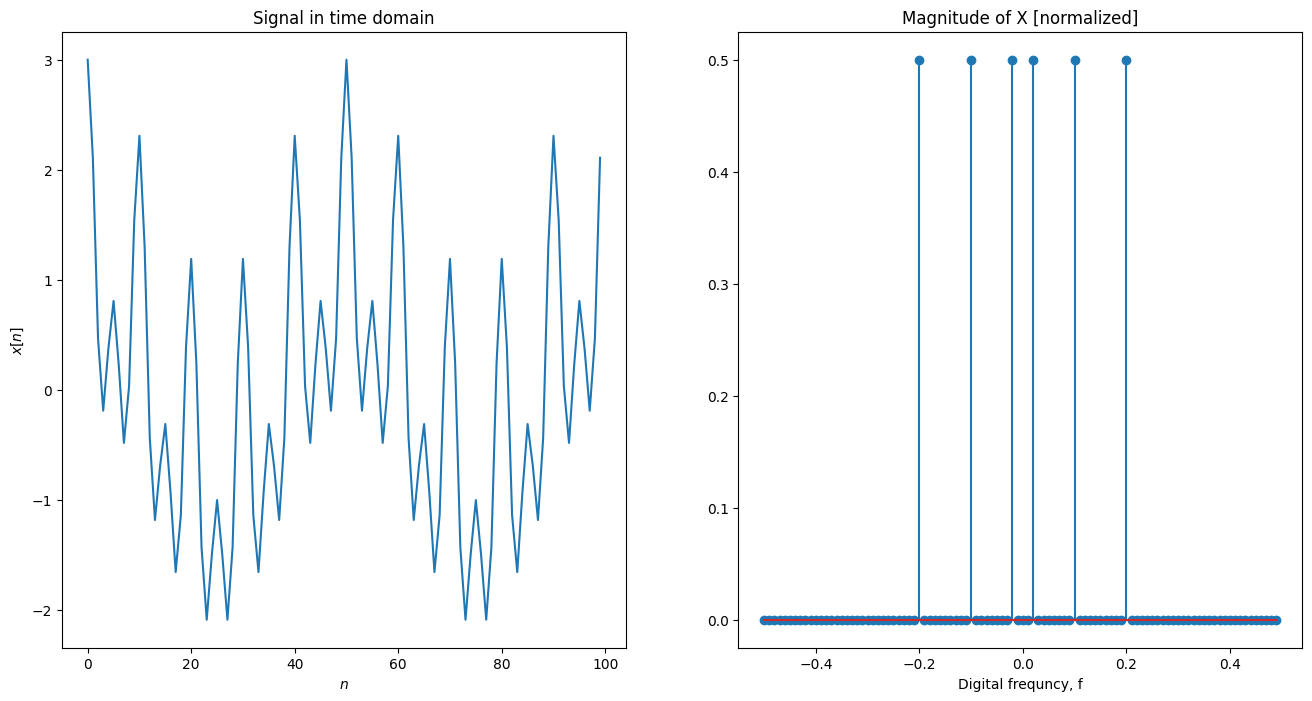

In [76]:
n_cycles_1 = 2
n_cycles_2 = 10
n_cycles_3 = 20
N = 100

f1 = n_cycles_1/N
f2 = n_cycles_2/N
f3 = n_cycles_3/N
n = np.arange(N)
x = np.cos(2*np.pi*f1*n) + np.cos(2*np.pi*f2*n) + np.cos(2*np.pi*f3*n)

X, fk = perform_fft(x, N)
plot_sig_and_fft(x, n, X, fk)

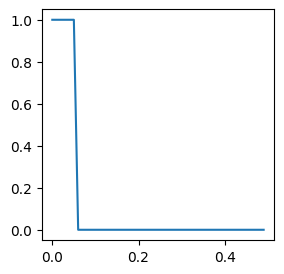

In [77]:
f_thres = 0.05

H_lp_ideal = np.zeros_like(fk)
H_lp_ideal[np.abs(fk) <= f_thres] = 1

fig = plt.figure(figsize=(3, 3))
plt.plot(fk[fk>=0], H_lp_ideal[fk>=0])

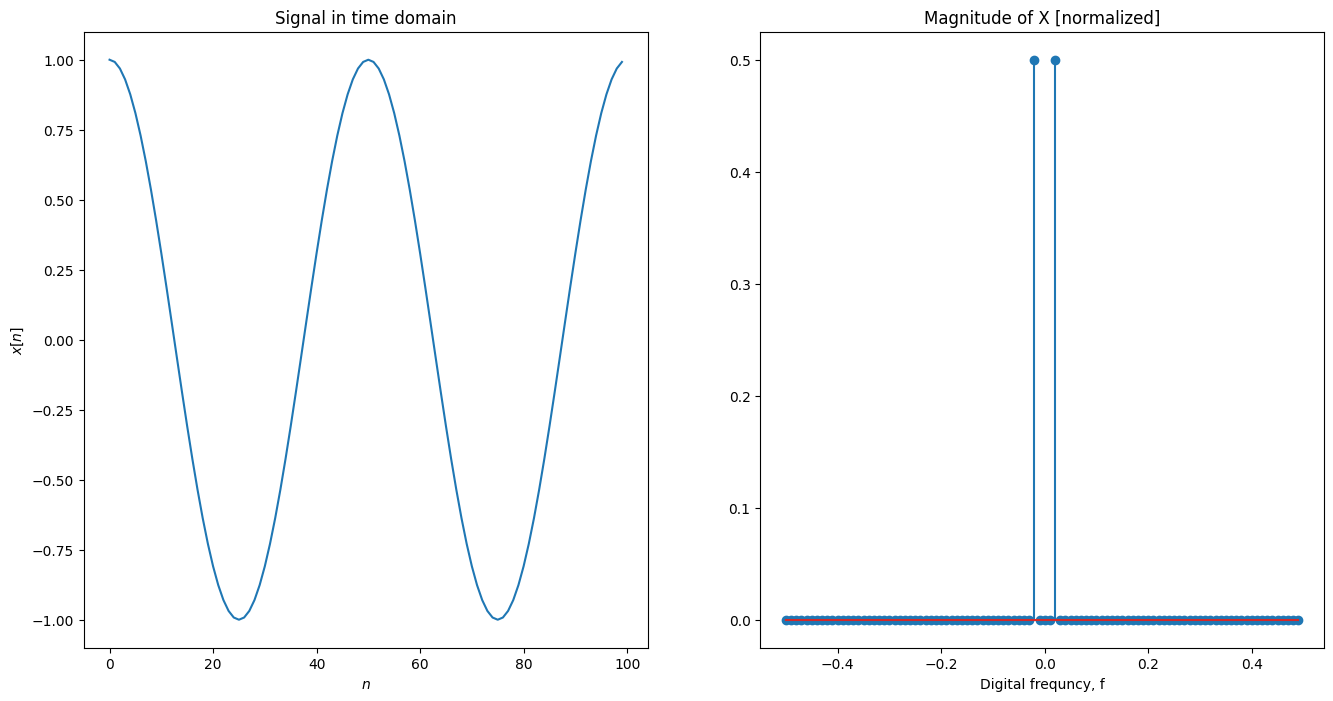

In [78]:
X_filtered_1 = X*H_lp_ideal
x_recon, n_recon = perform_ifft(X_filtered_1, N)
plot_sig_and_fft(x_recon, n_recon, X_filtered_1, fk)